In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 56.4 MB/s eta 0:00:00


In [ ]:
%pip install GEOparse

In [ ]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

Dataset Retrieval

In [ ]:
# Load 1st Dataset containing AD patients
gse1 = GEOparse.get_GEO(geo="GSE48350", destdir="./")

29-Jun-2025 10:54:25 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
29-Jun-2025 10:54:25 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350/soft/GSE48350_family.soft.gz to ./GSE48350_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350/soft/GSE48350_family.soft.gz to ./GSE48350_family.soft.gz
100%|██████████| 151M/151M [00:00<00:00, 243MB/s]
29-Jun-2025 10:54:26 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
29-Jun-2025 10:54:26 DEBUG downloader - Moving /tmp/tmp7tak7l3m to /content/GSE48350_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp7tak7l3m to /content/GSE48350_family.soft.gz
29-Jun-2025 10:54:30 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350/soft/GSE48350_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE48nnn/GSE48350

In [ ]:
# Extract expression data and metadata
expression_data1 = gse1.pivot_samples('VALUE')
metadata1 = gse1.phenotype_data

In [ ]:
print(expression_data1.shape)
print(metadata1.columns)

(54675, 253)
Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.individual',
       'characteristics_ch1.1.brain region', 'characteristics_ch1.2.gender',
       'characteristics_ch1.3.age (yrs)', 'treatment_protocol_ch1',
       'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1',
       'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol',
       'description', 'data_processing', 'platform_id', 'contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'relation', 'series_id',
       'data_row_count', 'characteristics_ch1.0.gender',
       'characteristics_ch1.1.age (yrs)', 'characteristics_ch1.2.brain region',
       'cha

In [ ]:
#Drop Unnecessary Columns
columns_to_drop1 = ['contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country']
metadatadrop1 = metadata1.drop(columns=columns_to_drop1)

In [ ]:
print(metadatadrop1.head())

                                               title geo_accession  \
GSM300166      PostcentralGyrus_female_91yrs_indiv10     GSM300166   
GSM300167  SuperiorFrontalGyrus_female_91yrs_indiv10     GSM300167   
GSM300168          Hippocampus_female_96yrs_indiv105     GSM300168   
GSM300169            Hippocampus_male_82yrs_indiv106     GSM300169   
GSM300170            Hippocampus_male_84yrs_indiv108     GSM300170   

                          status submission_date last_update_date type  \
GSM300166  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300167  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300168  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300169  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300170  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   

          channel_count                                  source_name_ch1  \
GSM300166             1       brain, postcentral gyrus, fe

In [ ]:
# Load 2nd Dataset containing Normal/Control Patients
gse2 = GEOparse.get_GEO(geo="GSE11882", destdir="./")

29-Jun-2025 10:55:29 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
29-Jun-2025 10:55:29 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11882/soft/GSE11882_family.soft.gz to ./GSE11882_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11882/soft/GSE11882_family.soft.gz to ./GSE11882_family.soft.gz
100%|██████████| 120M/120M [00:00<00:00, 216MB/s]
29-Jun-2025 10:55:30 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
29-Jun-2025 10:55:30 DEBUG downloader - Moving /tmp/tmp10ape4ym to /content/GSE11882_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp10ape4ym to /content/GSE11882_family.soft.gz
29-Jun-2025 10:55:30 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11882/soft/GSE11882_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE11nnn/GSE11882

In [ ]:
# Extract expression data and metadata
expression_data2 = gse2.pivot_samples('VALUE')
metadata2 = gse2.phenotype_data

In [ ]:
print(metadata2.columns)

Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.individual',
       'characteristics_ch1.1.brain region', 'characteristics_ch1.2.gender',
       'characteristics_ch1.3.age (yrs)', 'treatment_protocol_ch1',
       'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1',
       'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol',
       'description', 'data_processing', 'platform_id', 'contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'relation', 'series_id',
       'data_row_count'],
      dtype='object')


In [ ]:
# Drop Unnecessary Columns
columns_to_drop2 = ['contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country']
metadatadrop2 = metadata2.drop(columns=columns_to_drop2)

In [ ]:
print(metadatadrop2.head())

                                               title geo_accession  \
GSM300166      PostcentralGyrus_female_91yrs_indiv10     GSM300166   
GSM300167  SuperiorFrontalGyrus_female_91yrs_indiv10     GSM300167   
GSM300168          Hippocampus_female_96yrs_indiv105     GSM300168   
GSM300169            Hippocampus_male_82yrs_indiv106     GSM300169   
GSM300170            Hippocampus_male_84yrs_indiv108     GSM300170   

                          status submission_date last_update_date type  \
GSM300166  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300167  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300168  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300169  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300170  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   

          channel_count                                  source_name_ch1  \
GSM300166             1       brain, postcentral gyrus, fe

In [ ]:
# Find common genes between the two datasets
common_genes = expression_data1.index.intersection(expression_data2.index)
expr1 = expression_data1.loc[common_genes]
expr2 = expression_data2.loc[common_genes]

In [ ]:
# Combined Expression data and Metadata
combined_expr = pd.concat([expr1, expr2], axis=1)
combined_meta = pd.concat([metadatadrop1, metadatadrop2], axis=0)

In [ ]:
# Access platform annotations
platform = gse1.gpls['GPL570'].table

In [ ]:
print(platform)

                    ID  GB_ACC    SPOT_ID Species Scientific Name  \
0            1007_s_at  U48705        NaN            Homo sapiens   
1              1053_at  M87338        NaN            Homo sapiens   
2               117_at  X51757        NaN            Homo sapiens   
3               121_at  X69699        NaN            Homo sapiens   
4            1255_g_at  L36861        NaN            Homo sapiens   
...                ...     ...        ...                     ...   
54670   AFFX-ThrX-5_at     NaN  --Control            Homo sapiens   
54671   AFFX-ThrX-M_at     NaN  --Control            Homo sapiens   
54672  AFFX-TrpnX-3_at     NaN  --Control            Homo sapiens   
54673  AFFX-TrpnX-5_at     NaN  --Control            Homo sapiens   
54674  AFFX-TrpnX-M_at     NaN  --Control            Homo sapiens   

      Annotation Date      Sequence Type                  Sequence Source  \
0         Oct 6, 2014  Exemplar sequence  Affymetrix Proprietary Database   
1         Oct 6, 

In [ ]:
# Correctly assign disease status
combined_meta['braak_stage'] = combined_meta['characteristics_ch1.3.braak stage'].fillna('Not available')
combined_meta['disease_status'] = combined_meta['braak_stage'].apply(
    lambda x: 'AD' if x in ['III', 'IV', 'V', 'VI'] else
             'Normal' if x in ['0', 'I', 'II'] else
             'Normal' if 'cognitively intact' in combined_meta.loc[combined_meta['braak_stage'] == x, 'description'].iloc[0].lower()
             else 'AD'
)

In [ ]:
# Define genes of interest and their probes from platform GPL570
gene_probes = {
    'APOE': ['203381_s_at', '203382_s_at', '212884_x_at'],
    'APP': ['200602_at', '201981_at', '201982_s_at'],
    'PSEN1': ['1559206_at', '1567440_at', '1567443_x_at'],
    'PSEN2': ['204261_s_at', '204262_s_at', '211373_s_at'],
    'TREM2': ['219725_at'],
    'MAPT': ['203928_x_at', '203929_s_at', '203930_s_at']
}

In [ ]:
# Calculate mean expression for each gene
gene_expr = {}
for gene in gene_probes.keys():
    available_probes = [p for p in gene_probes[gene] if p in combined_expr.index]
    gene_expr[gene] = combined_expr.loc[available_probes].mean(axis=0)
gene_expr_df = pd.DataFrame(gene_expr)

In [ ]:
# Extract and clean metadata features
combined_meta['age'] = combined_meta['characteristics_ch1.3.age (yrs)'].str.extract(r'(\d+)').astype(float)
combined_meta['sex'] = combined_meta['characteristics_ch1.2.gender'].str.extract(r'gender: (\w+)')
combined_meta['brain_area'] = combined_meta['characteristics_ch1.1.brain region'].str.extract(r'brain region: (\w+)')

In [ ]:
# Encode categorical variables
combined_meta['sex'] = combined_meta['sex'].map({'male': 0, 'female': 1})
brain_area_dummies = pd.get_dummies(combined_meta['brain_area'], prefix='brain_area')

In [ ]:
# Reset indices to avoid duplicates
combined_meta = combined_meta.reset_index(drop=True)
brain_area_dummies = brain_area_dummies.reset_index(drop=True)
gene_expr_df = gene_expr_df.reset_index(drop=True)

# Combine all features
features = pd.concat([combined_meta[['age', 'sex']], brain_area_dummies, gene_expr_df], axis=1)

# Remove any rows with missing values
features = features.dropna()

# Get target (assuming disease_status is in combined_meta)
target = combined_meta.loc[features.index, 'disease_status'].map({'Normal': 0, 'AD': 1})

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Impute missing values
num_imputer = SimpleImputer(strategy='median')
combined_meta['age'] = num_imputer.fit_transform(combined_meta[['age']])

cat_imputer = SimpleImputer(strategy='most_frequent')
combined_meta['sex'] = cat_imputer.fit_transform(combined_meta[['sex']])

gene_expr_df = gene_expr_df.apply(lambda col: num_imputer.fit_transform(col.values.reshape(-1, 1)).ravel())

# Combine features
features = pd.concat([combined_meta[['age', 'sex']], brain_area_dummies, gene_expr_df], axis=1)

# Check for remaining issues
print("Shape of features:", features.shape)
print("Missing values in features:", features.isnull().sum().sum())

# Define target
target = combined_meta.loc[features.index, 'disease_status'].map({'Normal': 0, 'AD': 1})

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Shape of features: (426, 8)
Missing values in features: 0
Training set shape: (340, 8)
Testing set shape: (86, 8)


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['sex']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Convert targets to NumPy arrays
y_train_np = y_train.values
y_test_np = y_test.values

# Define the model
model = Sequential([
    Dense(64, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train_np,
                    validation_data=(X_test_scaled, y_test_np),
                    epochs=200,
                    batch_size=16)

Epoch 1/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.6867 - loss: 0.6511 - val_accuracy: 0.8488 - val_loss: 0.5173
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8073 - loss: 0.5365 - val_accuracy: 0.8488 - val_loss: 0.4443
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8222 - loss: 0.5071 - val_accuracy: 0.8488 - val_loss: 0.4095
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8277 - loss: 0.4437 - val_accuracy: 0.8488 - val_loss: 0.3979
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8405 - loss: 0.3966 - val_accuracy: 0.8488 - val_loss: 0.3864
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8212 - loss: 0.4182 - val_accuracy: 0.8488 - val_loss: 0.3755
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8344 - loss: 0.3673 - val_accuracy: 0.8488 - val_loss: 0.3656
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8335 - loss: 0.3725 - val_accuracy: 0.8

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_np)
print("Test accuracy:", test_acc)

# Predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int")

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test_np, y_pred))
print(classification_report(y_test_np, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8794 - loss: 0.1680
Test accuracy: 0.8837209343910217
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[70  3]
 [ 7  6]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        73
           1       0.67      0.46      0.55        13

    accuracy                           0.88        86
   macro avg       0.79      0.71      0.74        86
weighted avg       0.87      0.88      0.87        86



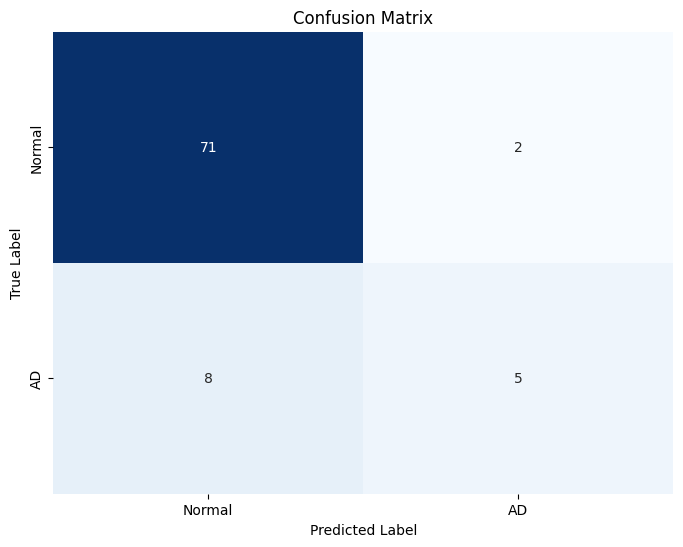

In [ ]:
from sklearn.metrics import confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'AD'], yticklabels=['Normal', 'AD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()